Klasifikasi Jamur dengan K-Nearest Neighbor (KNN)
Dataset: Mushroom Classification (Kaggle)

**Tujuan:** Memprediksi apakah jamur **beracun (p)** atau **bisa dimakan (e)** berdasarkan ciri-cirinya.

---

Import Library

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

uploaded = files.upload()

Saving mushrooms.csv to mushrooms (2).csv


Load Dataset

In [43]:
df = pd.read_csv('mushrooms.csv')

print('Ukuran dataset:', df.shape)
print()
df.head()

Ukuran dataset: (8124, 23)



,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Eksplorasi Data (EDA)

In [44]:
# Cek informasi umum
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  sta

In [45]:
# Cek nilai null
print('=== CEK MISSING VALUES ===')
print(df.isnull().sum())
print()
print('Total missing values:', df.isnull().sum().sum())

=== CEK MISSING VALUES ===
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Total missing values: 0


=== DISTRIBUSI KELAS ===
class
e    4208
p    3916
Name: count, dtype: int64

e = edible (bisa dimakan)
p = poisonous (beracun)


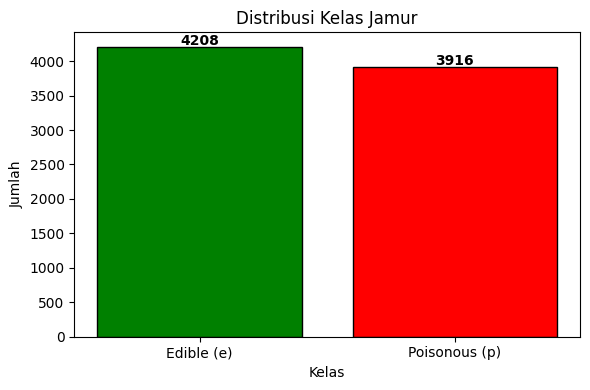

In [46]:
# Distribusi kelas target
print('=== DISTRIBUSI KELAS ===')
print(df['class'].value_counts())
print()
print('e = edible (bisa dimakan)')
print('p = poisonous (beracun)')

# Visualisasi - gunakan value_counts() sebagai angka
counts = df['class'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Edible (e)', 'Poisonous (p)'], counts.values, color=['green', 'red'], edgecolor='black')
plt.title('Distribusi Kelas Jamur')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

 Preprocessing Data

 **Kenapa perlu preprocessing?**
 Dataset ini semua kolomnya berupa **kategori (huruf)**, sedangkan KNN hanya bisa bekerja dengan **angka**.
 Kita perlu mengubah semua kolom kategori ke angka menggunakan **Label Encoding**.

In [47]:
# Label Encoding: ubah semua kolom kategorik ke numerik
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('Encoding selesai! Contoh hasil:')
print(df_encoded.head())

Encoding selesai! Contoh hasil:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk-color-above-ring  stalk-color-below-ring  vei

In [48]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop('class', axis=1)   # semua kolom kecuali 'class'
y = df_encoded['class']                # kolom target: 0=edible, 1=poisonous

print('Bentuk X (fitur):', X.shape)
print('Bentuk y (target):', y.shape)
print()
print('Nilai unik y:', y.unique(), '→ 0=edible, 1=poisonous')

Bentuk X (fitur): (8124, 22)
Bentuk y (target): (8124,)

Nilai unik y: [1 0] → 0=edible, 1=poisonous


In [49]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Jumlah data training:', X_train.shape[0])
print('Jumlah data testing :', X_test.shape[0])

Jumlah data training: 6499
Jumlah data testing : 1625


 Melatih Model KNN

In [50]:
# Buat dan latih model KNN dengan K=5
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

print('Model KNN berhasil dilatih dengan K=5')

Model KNN berhasil dilatih dengan K=5


Evaluasi Model

In [51]:
# Prediksi data test
y_pred = model.predict(X_test)

# Akurasi
acc = accuracy_score(y_test, y_pred)
print('=== HASIL EVALUASI ===')
print(f'Akurasi: {acc * 100:.2f}%')
print()

# Classification Report
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

=== HASIL EVALUASI ===
Akurasi: 99.63%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Edible       1.00      0.99      1.00       843
   Poisonous       0.99      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



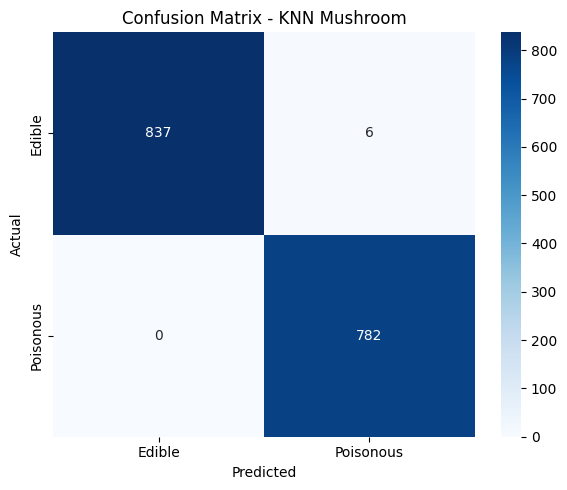

In [52]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title('Confusion Matrix - KNN Mushroom')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

 Mencari Nilai K Terbaik (Elbow Method)

K terbaik: 2 dengan akurasi test: 100.00%


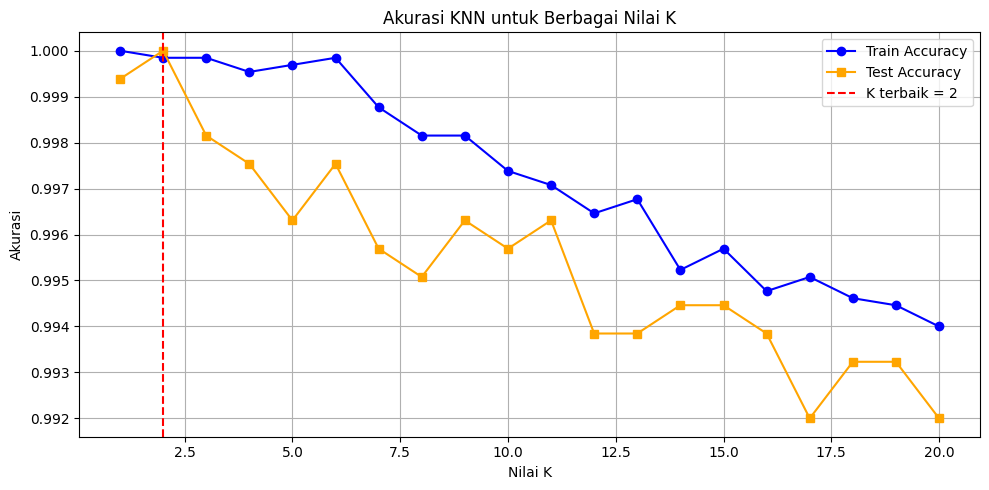

In [53]:
# Coba K dari 1 sampai 20, lihat akurasi mana yang terbaik
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

best_k = k_range[test_scores.index(max(test_scores))]
print(f'K terbaik: {best_k} dengan akurasi test: {max(test_scores)*100:.2f}%')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, label='Train Accuracy', marker='o', color='blue')
plt.plot(k_range, test_scores, label='Test Accuracy', marker='s', color='orange')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K terbaik = {best_k}')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.title('Akurasi KNN untuk Berbagai Nilai K')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

 Prediksi Data Baru
Contoh: memprediksi satu jamur baru

In [54]:
# Ambil 1 baris dari data test sebagai contoh
contoh = X_test.iloc[[0]]
prediksi = model.predict(contoh)
probabilitas = model.predict_proba(contoh)

label = 'BERACUN ' if prediksi[0] == 1 else 'AMAN dimakan '
print(f'Prediksi: {label}')
print(f'Probabilitas Edible   : {probabilitas[0][0]*100:.1f}%')
print(f'Probabilitas Poisonous: {probabilitas[0][1]*100:.1f}%')

Prediksi: AMAN dimakan 
Probabilitas Edible   : 100.0%
Probabilitas Poisonous: 0.0%


---
 Ringkasan

| Langkah | Keterangan |
|---|---|
| Dataset | 8.124 jamur, 22 fitur, semua kategorikal |
| Preprocessing | Label Encoding (kategori → angka) |
| Split | 80% train, 20% test |
| Model | KNN (n_neighbors=5) |
| Evaluasi | Accuracy, Precision, Recall, Confusion Matrix |
| Tuning | Elbow Method untuk cari K terbaik |

 **Catatan:** Dataset ini tidak menggunakan StandardScaler karena data sudah di-encode ke angka kecil (kategori) yang tidak memiliki perbedaan skala ekstrem.